<a href="https://colab.research.google.com/github/MichaelPerlock/DCF-Engine/blob/main/Code_For_Intrinsic_Stock_Valuation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[MO] 1. Fetching live market and fundamental data...
[MO] Calculated Reinvestment Rate: 1.07%
[MO] 2. Calculating dynamic Cost of Capital (WACC)...
[MO] 3. Running 10,000 Monte Carlo simulations...
[MO] 4. Generating Institutional Output...


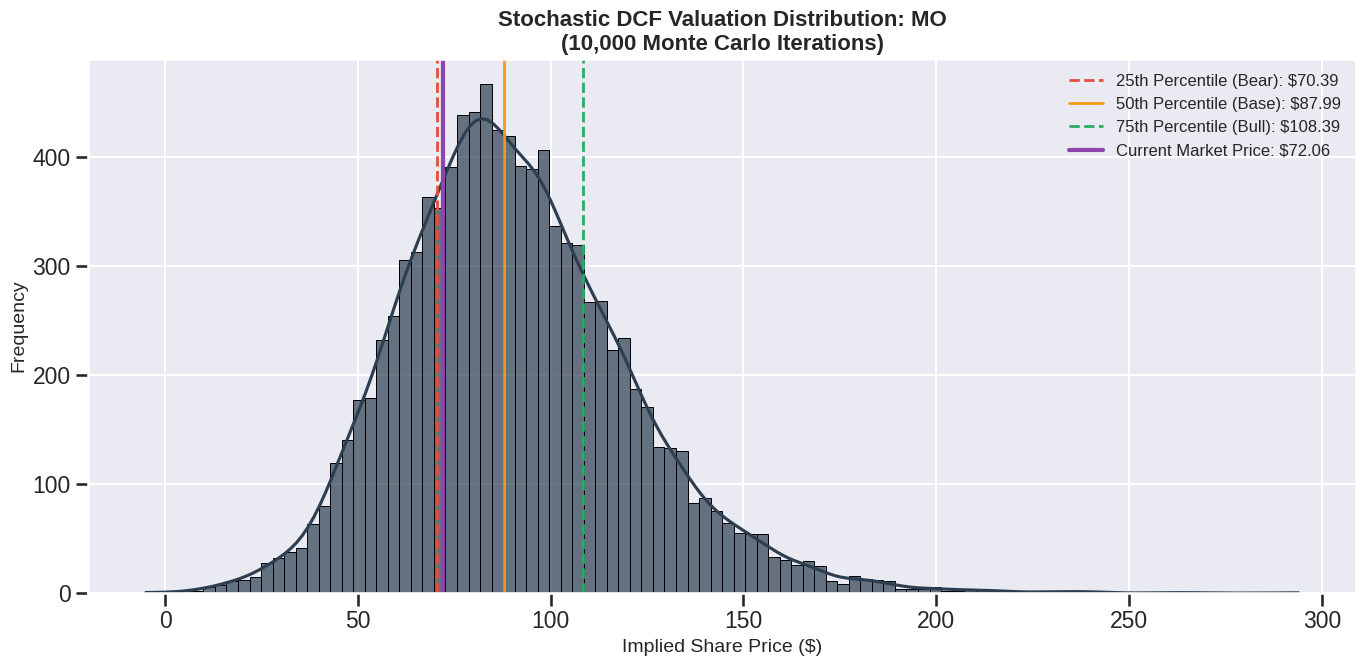


======== MO STOCHASTIC VALUATION RESULTS =========
Current Market Price:       $72.06
Implied Base Case (Median): $87.99
--------------------------------------------------
Margin of Safety:           +22.10%
VERDICT:                    [ BUY / UNDERVALUED ]



In [18]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# Set professional plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("talk")

TICKER = "MO"  #Company Ticker
ITERATIONS = 10000
PROJECTION_YEARS = 10

print(f"[{TICKER}] 1. Fetching live market and fundamental data...")
stock = yf.Ticker(TICKER)

# 1. Pull Historical Data
income_stmt = stock.financials.T[::-1]
revenues = income_stmt['Total Revenue']
ebit = income_stmt['EBIT']

historical_growth = revenues.pct_change().dropna()
historical_margins = ebit / revenues

growth_dist = {'mean': historical_growth.mean(), 'std': historical_growth.std()}
margin_dist = {'mean': historical_margins.mean(), 'std': historical_margins.std()}

shares_outstanding = stock.info.get('sharesOutstanding')
current_price = stock.history(period="1d")['Close'].iloc[-1]
current_revenue = revenues.iloc[-1]

# --- AUTOMATED REINVESTMENT RATE CALCULATOR ---
cash_flow_stmt = stock.cashflow.T[::-1]
try:
    # Pull actual Capital Expenditures and divide by Revenue
    recent_capex = abs(cash_flow_stmt['Capital Expenditure'].iloc[-1])
    REINVESTMENT_RATE = recent_capex / current_revenue
except (KeyError, AttributeError):
    # Fallback to 10% if the data is missing from the SEC filing
    REINVESTMENT_RATE = 0.10
print(f"[{TICKER}] Calculated Reinvestment Rate: {REINVESTMENT_RATE*100:.2f}%")
# Balance Sheet parsing
try:
    total_debt = stock.balance_sheet.loc['Total Debt'].iloc[0]
    total_cash = stock.balance_sheet.loc['Cash And Cash Equivalents'].iloc[0]
    net_debt = total_debt - total_cash
except (KeyError, AttributeError):
    total_debt = stock.info.get('totalDebt', 0)
    total_cash = stock.info.get('totalCash', 0)
    net_debt = total_debt - total_cash

print(f"[{TICKER}] 2. Calculating dynamic Cost of Capital (WACC)...")
# WACC Calculation
tnx = yf.Ticker("^TNX")
risk_free_rate = tnx.history(period="1d")['Close'].iloc[-1] / 100
beta = stock.info.get('beta', 1.0)
market_risk_premium = 0.055
cost_of_equity = risk_free_rate + (beta * market_risk_premium)

try:
    interest_expense = abs(income_stmt['Interest Expense'].iloc[-1])
    cost_of_debt = interest_expense / total_debt
except (KeyError, ZeroDivisionError):
    cost_of_debt = 0.05

tax_rate = stock.info.get('taxRate', 0.21)
after_tax_cost_of_debt = cost_of_debt * (1 - tax_rate)

market_cap = stock.info.get('marketCap')
total_capital = market_cap + total_debt
weight_equity = market_cap / total_capital
weight_debt = total_debt / total_capital

wacc = (weight_equity * cost_of_equity) + (weight_debt * after_tax_cost_of_debt)
wacc_dist = {'mean': wacc, 'std': 0.005}
terminal_g_dist = {'mean': 0.025, 'std': 0.005}

print(f"[{TICKER}] 3. Running 10,000 Monte Carlo simulations...")
# Monte Carlo Engine
np.random.seed(42)
sim_growth = np.random.normal(growth_dist['mean'], growth_dist['std'], ITERATIONS)
sim_margin = np.random.normal(margin_dist['mean'], margin_dist['std'], ITERATIONS)
sim_wacc = np.random.normal(wacc_dist['mean'], wacc_dist['std'], ITERATIONS)
sim_terminal_g = np.random.normal(terminal_g_dist['mean'], terminal_g_dist['std'], ITERATIONS)

intrinsic_values = []

for i in range(ITERATIONS):
    current_wacc = sim_wacc[i]
    tg = min(sim_terminal_g[i], current_wacc - 0.01)

    projected_fcf = []
    rev = current_revenue

    for year in range(1, PROJECTION_YEARS + 1):
        rev *= (1 + sim_growth[i])
        current_ebit = rev * sim_margin[i]
        nopat = current_ebit * (1 - tax_rate)
        reinvestment = rev * REINVESTMENT_RATE # Using our 5% fix here
        fcf = nopat - reinvestment

        pv_fcf = fcf / ((1 + current_wacc) ** year)
        projected_fcf.append(pv_fcf)

    final_year_fcf = projected_fcf[-1] * ((1 + current_wacc) ** PROJECTION_YEARS)
    terminal_value = (final_year_fcf * (1 + tg)) / (current_wacc - tg)
    pv_terminal_value = terminal_value / ((1 + current_wacc) ** PROJECTION_YEARS)

    enterprise_value = sum(projected_fcf) + pv_terminal_value
    equity_value = enterprise_value - net_debt

    implied_share_price = equity_value / shares_outstanding
    intrinsic_values.append(implied_share_price)

results = np.array(intrinsic_values)
implied_base_case = np.median(results)
margin_of_safety = (implied_base_case - current_price) / current_price

print(f"[{TICKER}] 4. Generating Institutional Output...")
# Plotting the Mountain
plt.figure(figsize=(14, 7))
sns.histplot(results, bins=100, kde=True, color='#2c3e50', alpha=0.7)

p25 = np.percentile(results, 25)
p75 = np.percentile(results, 75)

plt.axvline(p25, color='#e74c3c', linestyle='--', linewidth=2, label=f'25th Percentile (Bear): ${p25:.2f}')
plt.axvline(implied_base_case, color='#f39c12', linestyle='-', linewidth=2, label=f'50th Percentile (Base): ${implied_base_case:.2f}')
plt.axvline(p75, color='#27ae60', linestyle='--', linewidth=2, label=f'75th Percentile (Bull): ${p75:.2f}')
plt.axvline(current_price, color='#8e44ad', linestyle='-', linewidth=3, label=f'Current Market Price: ${current_price:.2f}')

plt.title(f'Stochastic DCF Valuation Distribution: {TICKER}\n(10,000 Monte Carlo Iterations)', fontsize=16, fontweight='bold')
plt.xlabel('Implied Share Price ($)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

# Final Report
print("\n" + "="*50)
print(f" {TICKER} STOCHASTIC VALUATION RESULTS ".center(50, "="))
print("="*50)
print(f"Current Market Price:       ${current_price:.2f}")
print(f"Implied Base Case (Median): ${implied_base_case:.2f}")
print("-"*50)
if margin_of_safety > 0:
    print(f"Margin of Safety:           +{margin_of_safety*100:.2f}%")
    print("VERDICT:                    [ BUY / UNDERVALUED ]")
else:
    print(f"Margin of Safety:           {margin_of_safety*100:.2f}%")
    print("VERDICT:                    [ OVERVALUED / PASS ]")
print("="*50 + "\n")